# Notebook 04 — Baseline Econometric Models

## 1. Notebook Purpose

This notebook estimates the **baseline** econometric models linking individual
and country-level determinants to employment probability, using the final
cleaned dataset produced by `notebooks/03_data_engineering_and_final_dataset.ipynb`.

**Boundaries**
- Uses `data/pickle/final_employment_ai_dataset.pkl` exactly as saved — **no data
  engineering, recoding, or new variables are created here**.
- **No machine learning models.**
- **No interaction terms and no advanced robustness checks** — those belong to
  `notebooks/05_advanced_econometric_models.ipynb`.
- Only association language is used ("is associated with", "predicts",
  "correlates with", "is linked to") — **no causal claims**.

**Dependent variable**: `employed`

**Candidate independent variables** (used if present in the final dataset):
`education_years`, `digital_readiness`, `female`, `children_household`,
`migration_background`, `health_status`, `age`, `age_squared`, `married`,
`household_size`, `institutional_trust_index`, `discrimination_experience`,
`ai_adoption_enterprises_pct`, and `country` (used only as a fixed-effects control
in Model 4).

**Hypotheses tested in this notebook**
- **H1**: Higher education and stronger digital readiness are associated with
  higher employment probability.
- **H2**: Country-level AI adoption is associated with employment probability
  after controlling for individual characteristics.
- **H3**: Women and individuals with family responsibilities may have different
  employment probabilities.
- **H4**: Migration background is associated with employment probability.
- **H5**: Health, institutional trust, and discrimination experience are relevant
  employment determinants.

**Notebook structure**
1. Notebook purpose
2. Load final cleaned dataset
3. Check modelling variables
4. Prepare baseline modelling sample
5. Descriptive check of modelling sample
6. Model 1: Linear Probability Model
7. Model 2: Logit Model
8. Model 3: Probit Model
9. Model 4: Logit with country fixed effects (if possible)
10. Marginal effects and odds ratios
11. Model comparison table
12. Baseline hypothesis interpretation
13. Save outputs

**Outputs saved**
- `outputs/tables/baseline_econometric_results.xlsx`
- `outputs/tables/baseline_model_sample_summary.xlsx`
- `outputs/figures/baseline_coefficients.png`
- `outputs/reports/baseline_econometric_interpretation.md`

This notebook saves all results so it does not need to be rerun every time it is
read or cited from the thesis text.

## 2. Environment Setup and Load Final Cleaned Dataset

Run the install cell below **once** if you get a `ModuleNotFoundError` (for
example, `No module named 'pandas'`) — skip it if packages are already installed.
Make sure the correct kernel/virtual environment is selected in VS Code before
running any other cell. Full setup instructions:
[docs/environment_setup.md](../docs/environment_setup.md).

In [1]:
# OPTIONAL: run only if a package is missing (e.g. ModuleNotFoundError: No module named 'pandas').
# Safe to skip if all packages in requirements.txt are already installed in this kernel.
from pathlib import Path

_project_root_for_install = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_requirements_path = _project_root_for_install / 'requirements.txt'

if not _requirements_path.exists():
    print(f'requirements.txt not found at {_requirements_path}. See docs/environment_setup.md.')
else:
    %pip install -r "{_requirements_path}"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports and path setup for this notebook (econometrics: pandas, numpy, matplotlib, statsmodels).
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import statsmodels.formula.api as smf
    from scipy import stats
except ImportError as exc:
    raise ImportError(
        f"Missing package: {exc.name}. Run the optional install cell above (or "
        "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
    ) from exc

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
PICKLE_DIR = DATA_DIR / 'pickle'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR = OUTPUTS_DIR / 'tables'
REPORTS_DIR = OUTPUTS_DIR / 'reports'
MODELS_DIR = OUTPUTS_DIR / 'models'
for d in [PROCESSED_DIR, PICKLE_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis


In [3]:
dataset_path = PICKLE_DIR / 'final_employment_ai_dataset.pkl'
if not dataset_path.exists():
    raise FileNotFoundError(
        f'{dataset_path} not found. Run notebooks/03_data_engineering_and_final_dataset.ipynb '
        'first to produce the final dataset. Do not proceed with simulated data.'
    )

df = pd.read_pickle(dataset_path)
print('Loaded final dataset:', dataset_path)
print('Shape:', df.shape)
df.head()

Loaded final dataset: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\data\pickle\final_employment_ai_dataset.pkl
Shape: (49837, 1291)


,employed,age,age_squared,female,education_years,education_level,high_education,married,children_household,household_size,...,reg11_soexgdp_2014,reg11_soexgdp_2015,reg11_soexgdp_2016,reg11_soexgdp_2017,reg11_soexgdp_2018,reg11_soexgdp_2019,reg11_soexgdp_2020,reg11_soexgdp_2021,reg11_soexgdp_2022,reg11_soexgdp_2023
0,0,65.0000,"4,225.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,21.0000,441.0000,1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,53.0000,"2,809.0000",1,16.0000,6.0000,1,1,0,3.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,78.0000,"6,084.0000",1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,64.0000,"4,096.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Check Modelling Variables

Checks which of the candidate variables actually exist in the final dataset, and
which contain enough non-missing data to be used in a regression. A variable that
exists but is entirely missing (e.g. because the underlying ESS source items were
not available when notebook 03 was last run) is excluded and documented, rather
than allowed to silently drop every row via listwise deletion.

In [4]:
DEPENDENT_VAR = 'employed'
CANDIDATE_VARS = [
    'education_years', 'digital_readiness', 'female', 'children_household',
    'migration_background', 'health_status', 'age', 'age_squared', 'married',
    'household_size', 'institutional_trust_index', 'discrimination_experience',
    'ai_adoption_enterprises_pct',
]
COUNTRY_VAR = 'country'

if DEPENDENT_VAR not in df.columns:
    raise KeyError(f'Dependent variable "{DEPENDENT_VAR}" not found in the final dataset. Cannot continue.')

variable_check = []
for var in CANDIDATE_VARS:
    if var not in df.columns:
        variable_check.append({'variable': var, 'status': 'missing (column not found)', 'non_missing_pct': np.nan})
    else:
        non_missing_pct = df[var].notna().mean() * 100
        status = 'available' if non_missing_pct > 0 else 'excluded (column exists but 100% missing)'
        variable_check.append({'variable': var, 'status': status, 'non_missing_pct': round(non_missing_pct, 2)})

variable_check_df = pd.DataFrame(variable_check)

available_vars = [
    row['variable'] for row in variable_check
    if row['status'] == 'available'
]
missing_vars = [row['variable'] for row in variable_check if row['status'] != 'available']

country_available = COUNTRY_VAR in df.columns and df[COUNTRY_VAR].notna().sum() > 0

print(f'{len(available_vars)} of {len(CANDIDATE_VARS)} candidate variables are usable for modelling.')
if missing_vars:
    print('Excluded from modelling (documented, not invented):', missing_vars)
print('Country variable available for fixed effects:', country_available)
variable_check_df

13 of 13 candidate variables are usable for modelling.
Country variable available for fixed effects: True


,variable,status,non_missing_pct
0,education_years,available,98.3900
1,digital_readiness,available,99.9000
2,female,available,100.0000
3,children_household,available,100.0000
4,migration_background,available,100.0000
5,health_status,available,99.8600
6,age,available,99.2800
7,age_squared,available,99.2800
8,married,available,100.0000
9,household_size,available,99.3900


## 4. Prepare Baseline Modelling Sample

Builds the modelling sample by selecting the dependent variable, all available
independent variables, and the country variable (kept for Model 4 only). Rows
with any missing value among the selected columns are dropped listwise; the
number of dropped rows is reported explicitly rather than silently absorbed.

In [5]:
model_columns = [DEPENDENT_VAR] + available_vars + ([COUNTRY_VAR] if country_available else [])
n_before = len(df)

sample = df[model_columns].dropna().copy()
n_after = len(sample)
n_dropped = n_before - n_after

print(f'Modelling sample: {n_after} of {n_before} rows kept ({n_dropped} rows dropped due to missing values in: {model_columns}).')
print('Final modelling sample shape:', sample.shape)
sample.head()

Modelling sample: 41265 of 49837 rows kept (8572 rows dropped due to missing values in: ['employed', 'education_years', 'digital_readiness', 'female', 'children_household', 'migration_background', 'health_status', 'age', 'age_squared', 'married', 'household_size', 'institutional_trust_index', 'discrimination_experience', 'ai_adoption_enterprises_pct', 'country']).
Final modelling sample shape: (41265, 15)


,employed,education_years,digital_readiness,female,children_household,migration_background,health_status,age,age_squared,married,household_size,institutional_trust_index,discrimination_experience,ai_adoption_enterprises_pct,country
0,0,12.0000,5.0000,0,0,0,3.0000,65.0000,"4,225.0000",1,2.0000,7.5000,0,29.9500,AT
1,0,14.0000,5.0000,1,0,0,2.0000,21.0000,441.0000,0,1.0000,4.2500,0,29.9500,AT
2,1,16.0000,5.0000,1,0,0,1.0000,53.0000,"2,809.0000",1,3.0000,6.0000,1,29.9500,AT
3,0,14.0000,1.0000,1,0,1,3.0000,78.0000,"6,084.0000",0,1.0000,5.7500,0,29.9500,AT
4,0,12.0000,5.0000,0,0,0,2.0000,64.0000,"4,096.0000",1,2.0000,6.7500,0,29.9500,AT


## 5. Descriptive Check of Modelling Sample

Confirms the modelling sample looks reasonable before fitting any model:
employment distribution, descriptive statistics of the independent variables, and
a correlation matrix to flag potential multicollinearity.

In [6]:
employed_distribution_sample = sample[DEPENDENT_VAR].value_counts(normalize=True)
print('Employed distribution in the modelling sample:')
print(employed_distribution_sample)

sample_summary = sample[available_vars + [DEPENDENT_VAR]].describe().T
sample_summary

Employed distribution in the modelling sample:
employed
1   0.5170
0   0.4830
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
education_years,"41,265.0000",13.2245,4.0495,0.0000,11.0000,13.0000,16.0000,69.0000
digital_readiness,"41,265.0000",4.1794,1.4312,1.0000,4.0000,5.0000,5.0000,5.0000
female,"41,265.0000",0.5356,0.4987,0.0000,0.0000,1.0000,1.0000,1.0000
children_household,"41,265.0000",0.2178,0.4128,0.0000,0.0000,0.0000,0.0000,1.0000
migration_background,"41,265.0000",0.0813,0.2733,0.0000,0.0000,0.0000,0.0000,1.0000
health_status,"41,265.0000",2.1701,0.9084,1.0000,2.0000,2.0000,3.0000,5.0000
age,"41,265.0000",51.8204,18.6010,15.0000,37.0000,53.0000,67.0000,90.0000
age_squared,"41,265.0000","3,031.3412","1,926.3852",225.0000,"1,369.0000","2,809.0000","4,489.0000","8,100.0000"
married,"41,265.0000",0.4930,0.5000,0.0000,0.0000,0.0000,1.0000,1.0000
household_size,"41,265.0000",2.5302,1.3105,0.0000,2.0000,2.0000,3.0000,13.0000


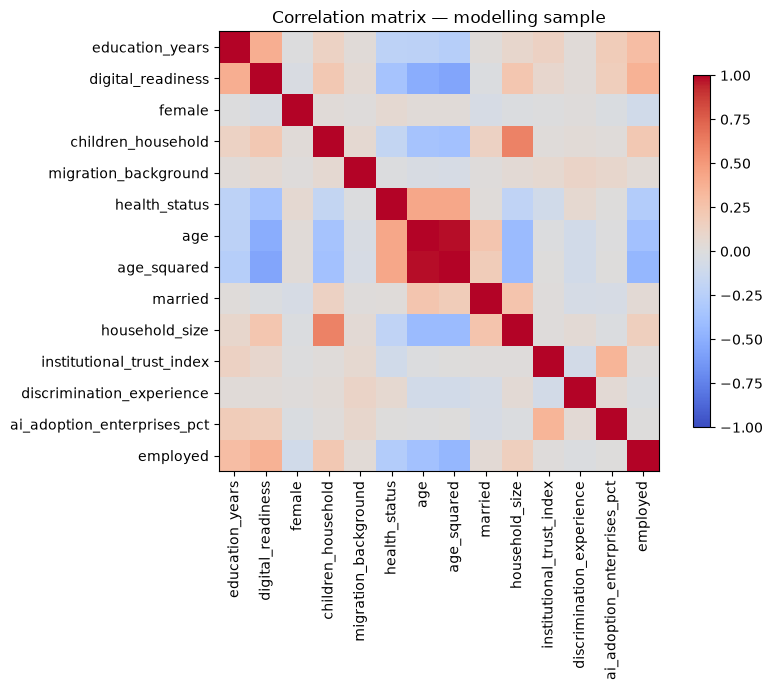


Variable pairs with |correlation| > 0.6 (possible multicollinearity, interpret with care):
children_household  household_size   0.6018
age                 age_squared      0.9827
dtype: float64


In [7]:
correlation_matrix = sample[available_vars + [DEPENDENT_VAR]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_yticklabels(correlation_matrix.columns)
ax.set_title('Correlation matrix — modelling sample')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

high_corr_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .loc[lambda s: s.abs() > 0.6]
)
if not high_corr_pairs.empty:
    print('\nVariable pairs with |correlation| > 0.6 (possible multicollinearity, interpret with care):')
    print(high_corr_pairs)
else:
    print('\nNo variable pairs with |correlation| > 0.6 detected.')

## 5a. Descriptive Statistics Split by Employment Outcome

For each of the 14 modelling variables, reports mean/SD/N separately for the
`employed = 1` and `employed = 0` groups, the mean difference (employed=1 minus
employed=0), and a group-comparison p-value: a Welch two-sample t-test for
continuous/ordinal variables, or a chi-square test of independence (against
`employed` itself) for binary (0/1) variables. The `employed` row itself is the
grouping variable and is reported for completeness (mean/SD/N by construction)
without a group-comparison test.

In [8]:
from scipy import stats

desc_split_vars = available_vars + [DEPENDENT_VAR]
desc_split_rows = []

for var in desc_split_vars:
    non_null_values = set(sample[var].dropna().unique())
    is_binary = non_null_values.issubset({0, 1})

    group1 = sample.loc[sample[DEPENDENT_VAR] == 1, var].dropna()
    group0 = sample.loc[sample[DEPENDENT_VAR] == 0, var].dropna()

    row = {
        'variable': var,
        'mean_employed_1': group1.mean(),
        'sd_employed_1': group1.std(),
        'n_employed_1': int(group1.shape[0]),
        'mean_employed_0': group0.mean(),
        'sd_employed_0': group0.std(),
        'n_employed_0': int(group0.shape[0]),
        'mean_difference': group1.mean() - group0.mean(),
    }

    if var == DEPENDENT_VAR:
        row['test_type'] = 'n/a (grouping variable itself)'
        row['test_statistic'] = np.nan
        row['p_value'] = np.nan
    elif is_binary:
        contingency = pd.crosstab(sample[var], sample[DEPENDENT_VAR])
        chi2_stat, chi2_p, _, _ = stats.chi2_contingency(contingency)
        row['test_type'] = 'chi-square'
        row['test_statistic'] = chi2_stat
        row['p_value'] = chi2_p
    else:
        t_stat, t_p = stats.ttest_ind(group1, group0, equal_var=False, nan_policy='omit')
        row['test_type'] = 't-test (Welch)'
        row['test_statistic'] = t_stat
        row['p_value'] = t_p

    desc_split_rows.append(row)

descriptive_statistics_by_outcome = pd.DataFrame(desc_split_rows)
print('Descriptive statistics split by employment outcome:')
descriptive_statistics_by_outcome

Descriptive statistics split by employment outcome:


,variable,mean_employed_1,sd_employed_1,n_employed_1,mean_employed_0,sd_employed_0,n_employed_0,mean_difference,test_type,test_statistic,p_value
0,education_years,14.3761,3.7448,21333,11.9920,4.0002,19932,2.3842,t-test (Welch),62.3923,0.0000
1,digital_readiness,4.6873,0.8402,21333,3.6359,1.7070,19932,1.0514,t-test (Welch),78.5254,0.0000
2,female,0.4929,0.5000,21333,0.5814,0.4933,19932,-0.0885,chi-square,323.9591,0.0000
3,children_household,0.3041,0.4600,21333,0.1254,0.3312,19932,0.1787,chi-square,"1,930.4462",0.0000
4,migration_background,0.0900,0.2861,21333,0.0721,0.2587,19932,0.0179,chi-square,43.7513,0.0000
5,health_status,1.9281,0.7704,21333,2.4291,0.9713,19932,-0.5010,t-test (Welch),-57.7855,0.0000
6,age,45.2116,12.2707,21333,58.8936,21.4102,19932,-13.6820,t-test (Welch),-78.9191,0.0000
7,age_squared,"2,194.6559","1,112.8634",21333,"3,926.8363","2,192.3052",19932,"-1,732.1805",t-test (Welch),-100.1438,0.0000
8,married,0.5151,0.4998,21333,0.4692,0.4991,19932,0.0459,chi-square,86.5651,0.0000
9,household_size,2.7343,1.2897,21333,2.3118,1.2973,19932,0.4225,t-test (Welch),33.1494,0.0000


## 6. Model 1: Linear Probability Model (LPM)

The Linear Probability Model regresses the binary `employed` outcome directly on
the independent variables using OLS, with **heteroskedasticity-robust (HC1)
standard errors** (the binary outcome mechanically produces non-constant error
variance, so robust standard errors are required for valid inference).

**Interpretation note**: LPM coefficients are directly interpretable as the change
in the *predicted probability* of employment for a one-unit change in the
independent variable. This makes it easy to communicate, but it has two well-known
limitations: predicted probabilities are not constrained to the [0, 1] range, and
the constant-effect assumption is unrealistic near the extremes of the probability
distribution. It is reported here as an intuitive baseline and cross-checked
against the Logit and Probit models below.

In [9]:
def extract_results(res, model_name, include_odds_ratio=False):
    """Builds a tidy results table (coef, std err, test stat, p-value, 95% CI,
    significance stars, optionally odds ratios) from a fitted statsmodels result.
    Used consistently for every model in this notebook so results stay comparable."""
    conf = res.conf_int()
    conf.columns = ['ci_low', 'ci_high']
    table = pd.DataFrame({
        'coef': res.params,
        'std_err': res.bse,
        'stat': res.tvalues,
        'p_value': res.pvalues,
    }).join(conf)
    table['sig'] = table['p_value'].apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))
    if include_odds_ratio:
        table['odds_ratio'] = np.exp(table['coef'])
        table['odds_ratio_ci_low'] = np.exp(table['ci_low'])
        table['odds_ratio_ci_high'] = np.exp(table['ci_high'])
    table = table.reset_index().rename(columns={'index': 'variable'})
    table.insert(0, 'model', model_name)
    return table


baseline_formula = f"{DEPENDENT_VAR} ~ {' + '.join(available_vars)}"
print('Baseline formula:', baseline_formula)

Baseline formula: employed ~ education_years + digital_readiness + female + children_household + migration_background + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct


In [10]:
lpm_res = smf.ols(baseline_formula, data=sample).fit(cov_type='HC1')
lpm_table = extract_results(lpm_res, 'LPM (OLS, robust HC1 SE)')

print(lpm_res.summary())
lpm_table

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     2311.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:14:17   Log-Likelihood:                -19706.
No. Observations:               41265   AIC:                         3.944e+04
Df Residuals:                   41251   BIC:                         3.956e+04
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig
0,"LPM (OLS, robust HC1 SE)",Intercept,-0.4605,0.0195,-23.5659,0.0000,-0.4988,-0.4222,***
1,"LPM (OLS, robust HC1 SE)",education_years,0.0114,0.0005,21.2112,0.0000,0.0104,0.0125,***
2,"LPM (OLS, robust HC1 SE)",digital_readiness,0.0119,0.0017,6.8428,0.0000,0.0085,0.0153,***
3,"LPM (OLS, robust HC1 SE)",female,-0.0723,0.0039,-18.7374,0.0000,-0.0799,-0.0647,***
4,"LPM (OLS, robust HC1 SE)",children_household,0.0691,0.0060,11.5361,0.0000,0.0574,0.0809,***
5,"LPM (OLS, robust HC1 SE)",migration_background,0.0011,0.0074,0.1516,0.8795,-0.0134,0.0157,
6,"LPM (OLS, robust HC1 SE)",health_status,-0.0498,0.0025,-19.8155,0.0000,-0.0547,-0.0449,***
7,"LPM (OLS, robust HC1 SE)",age,0.0546,0.0007,82.8857,0.0000,0.0533,0.0559,***
8,"LPM (OLS, robust HC1 SE)",age_squared,-0.0006,0.0000,-96.3022,0.0000,-0.0006,-0.0006,***
9,"LPM (OLS, robust HC1 SE)",married,-0.0128,0.0045,-2.8298,0.0047,-0.0217,-0.0039,***


## 7. Model 2: Logit Model

The Logit model is the **main baseline binary-outcome model** in this notebook. It
models the log-odds of employment as a linear function of the independent
variables, which naturally keeps predicted probabilities within [0, 1]. Both raw
coefficients (log-odds scale) and **odds ratios** (`exp(coefficient)`) are
reported: an odds ratio above 1 means the variable is associated with *higher*
odds of employment, and below 1 means *lower* odds, holding the other variables
constant.

In [11]:
logit_res = smf.logit(baseline_formula, data=sample).fit(disp=0)
logit_table = extract_results(logit_res, 'Logit', include_odds_ratio=True)

print(logit_res.summary())
logit_table

                           Logit Regression Results                           
Dep. Variable:               employed   No. Observations:                41265
Model:                          Logit   Df Residuals:                    41251
Method:                           MLE   Df Model:                           13
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.4165
Time:                        17:14:17   Log-Likelihood:                -16674.
converged:                       True   LL-Null:                       -28579.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -9.5314      0.154    -62.046      0.000      -9.832      -9.230
education_years                 0.0742      0.004     18.350      0.000       0.

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Logit,Intercept,-9.5314,0.1536,-62.0461,0.0000,-9.8325,-9.2303,***,0.0001,0.0001,0.0001
1,Logit,education_years,0.0742,0.0040,18.3503,0.0000,0.0662,0.0821,***,1.0770,1.0685,1.0855
2,Logit,digital_readiness,0.1801,0.0136,13.2113,0.0000,0.1534,0.2068,***,1.1973,1.1658,1.2298
3,Logit,female,-0.6149,0.0280,-21.9515,0.0000,-0.6698,-0.5600,***,0.5407,0.5118,0.5712
4,Logit,children_household,-0.1800,0.0417,-4.3139,0.0000,-0.2618,-0.0982,***,0.8352,0.7696,0.9064
5,Logit,migration_background,-0.0691,0.0492,-1.4052,0.1600,-0.1654,0.0273,,0.9333,0.8475,1.0276
6,Logit,health_status,-0.3710,0.0173,-21.4974,0.0000,-0.4048,-0.3371,***,0.6901,0.6671,0.7138
7,Logit,age,0.5125,0.0062,82.4500,0.0000,0.5003,0.5247,***,1.6694,1.6492,1.6899
8,Logit,age_squared,-0.0059,0.0001,-86.1785,0.0000,-0.0060,-0.0058,***,0.9941,0.9940,0.9943
9,Logit,married,0.0153,0.0327,0.4682,0.6397,-0.0488,0.0794,,1.0154,0.9524,1.0826


In [12]:
significant_logit_vars = logit_table.loc[(logit_table['variable'] != 'Intercept') & (logit_table['p_value'] < 0.05)]
print('Statistically significant variables in the baseline Logit model (p < 0.05):')
for _, row in significant_logit_vars.iterrows():
    direction = 'higher' if row['coef'] > 0 else 'lower'
    print(f"- {row['variable']}: associated with {direction} employment probability (odds ratio = {row['odds_ratio']:.3f}, p = {row['p_value']:.3f})")

Statistically significant variables in the baseline Logit model (p < 0.05):
- education_years: associated with higher employment probability (odds ratio = 1.077, p = 0.000)
- digital_readiness: associated with higher employment probability (odds ratio = 1.197, p = 0.000)
- female: associated with lower employment probability (odds ratio = 0.541, p = 0.000)
- children_household: associated with lower employment probability (odds ratio = 0.835, p = 0.000)
- health_status: associated with lower employment probability (odds ratio = 0.690, p = 0.000)
- age: associated with higher employment probability (odds ratio = 1.669, p = 0.000)
- age_squared: associated with lower employment probability (odds ratio = 0.994, p = 0.000)
- household_size: associated with lower employment probability (odds ratio = 0.911, p = 0.000)
- discrimination_experience: associated with lower employment probability (odds ratio = 0.627, p = 0.000)


## 8. Model 3: Probit Model

The Probit model is estimated as a **robustness check** for the Logit model. It
uses a different link function (the normal CDF instead of the logistic CDF), so
coefficients are not directly comparable in magnitude to Logit or LPM
coefficients — what matters is whether the **direction (sign)** and
**statistical significance** of each variable agree with the Logit results.
Marginal effects (average marginal effects, on the probability scale) are
reported in section 10 alongside the Logit marginal effects, which are directly
comparable across the two models.

In [13]:
probit_res = smf.probit(baseline_formula, data=sample).fit(disp=0)
probit_table = extract_results(probit_res, 'Probit')

print(probit_res.summary())
probit_table

                          Probit Regression Results                           
Dep. Variable:               employed   No. Observations:                41265
Model:                         Probit   Df Residuals:                    41251
Method:                           MLE   Df Model:                           13
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.4068
Time:                        17:14:18   Log-Likelihood:                -16954.
converged:                       True   LL-Null:                       -28579.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -5.1750      0.083    -62.424      0.000      -5.337      -5.013
education_years                 0.0423      0.002     19.001      0.000       0.

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig
0,Probit,Intercept,-5.1750,0.0829,-62.4240,0.0000,-5.3375,-5.0125,***
1,Probit,education_years,0.0423,0.0022,19.0014,0.0000,0.0380,0.0467,***
2,Probit,digital_readiness,0.0995,0.0077,12.9900,0.0000,0.0845,0.1146,***
3,Probit,female,-0.3399,0.0157,-21.5974,0.0000,-0.3708,-0.3091,***
4,Probit,children_household,-0.0395,0.0234,-1.6889,0.0912,-0.0853,0.0063,*
5,Probit,migration_background,-0.0431,0.0277,-1.5567,0.1195,-0.0973,0.0112,
6,Probit,health_status,-0.2081,0.0097,-21.3959,0.0000,-0.2272,-0.1890,***
7,Probit,age,0.2780,0.0032,87.6003,0.0000,0.2718,0.2842,***
8,Probit,age_squared,-0.0032,0.0000,-93.1455,0.0000,-0.0032,-0.0031,***
9,Probit,married,0.0061,0.0185,0.3297,0.7416,-0.0301,0.0423,


In [14]:
comparison_cols = ['variable']
logit_compare = logit_table.set_index('variable')[['coef', 'p_value']].rename(columns={'coef': 'logit_coef', 'p_value': 'logit_p'})
probit_compare = probit_table.set_index('variable')[['coef', 'p_value']].rename(columns={'coef': 'probit_coef', 'p_value': 'probit_p'})

logit_vs_probit = logit_compare.join(probit_compare)
logit_vs_probit['same_sign'] = np.sign(logit_vs_probit['logit_coef']) == np.sign(logit_vs_probit['probit_coef'])
logit_vs_probit['same_significance_at_5pct'] = (logit_vs_probit['logit_p'] < 0.05) == (logit_vs_probit['probit_p'] < 0.05)

print('Logit vs. Probit agreement check (direction and significance):')
logit_vs_probit

Logit vs. Probit agreement check (direction and significance):


,logit_coef,logit_p,probit_coef,probit_p,same_sign,same_significance_at_5pct
variable,,,,,,
Intercept,-9.5314,0.0000,-5.1750,0.0000,True,True
education_years,0.0742,0.0000,0.0423,0.0000,True,True
digital_readiness,0.1801,0.0000,0.0995,0.0000,True,True
female,-0.6149,0.0000,-0.3399,0.0000,True,True
children_household,-0.1800,0.0000,-0.0395,0.0912,True,False
migration_background,-0.0691,0.1600,-0.0431,0.1195,True,True
health_status,-0.3710,0.0000,-0.2081,0.0000,True,True
age,0.5125,0.0000,0.2780,0.0000,True,True
age_squared,-0.0059,0.0000,-0.0032,0.0000,True,True


## 9. Model 4: Logit with Country Fixed Effects

Country fixed effects control for **unobserved, time-invariant country-level
differences** (labour market institutions, culture, macroeconomic conditions not
otherwise captured) by adding a dummy variable for every country. This isolates
the within-country association between individual characteristics and
employment. `ai_adoption_enterprises_pct` cannot be estimated together with
country fixed effects, because it varies only *between* countries, not *within*
them — it would be collinear with the country dummies. It is therefore dropped
from this model only, and this is explicitly documented.

This model is estimated only if the country variable is available and has enough
variation (at least two countries, each with both employed and non-employed
respondents). Countries with only one outcome category would cause **perfect
separation** in a Logit model, which produces unreliable, non-converging
coefficient estimates; such countries are dropped from this model's sample only,
and this is documented rather than silently ignored.

In [15]:
fe_logit_res = None
fe_logit_table = pd.DataFrame()
fe_skip_reason = None

if not country_available:
    fe_skip_reason = 'Country variable not available in the final dataset.'
else:
    fe_sample = sample.copy()
    outcome_variation = fe_sample.groupby(COUNTRY_VAR)[DEPENDENT_VAR].nunique()
    countries_single_outcome = outcome_variation[outcome_variation < 2].index.tolist()

    if countries_single_outcome:
        n_before_fe_drop = len(fe_sample)
        fe_sample = fe_sample[~fe_sample[COUNTRY_VAR].isin(countries_single_outcome)].copy()
        print(
            f'Dropped {n_before_fe_drop - len(fe_sample)} rows from {len(countries_single_outcome)} '
            f'countries with only one employment outcome category (perfect separation risk): {countries_single_outcome}'
        )

    n_countries_fe = fe_sample[COUNTRY_VAR].nunique()
    fe_vars = [v for v in available_vars if v != 'ai_adoption_enterprises_pct']

    if n_countries_fe < 2:
        fe_skip_reason = (
            f'Only {n_countries_fe} country(ies) have variation in the employment outcome after '
             'removing single-outcome countries; fixed effects require at least two.'
        )
    else:
        fe_formula = f"{DEPENDENT_VAR} ~ {' + '.join(fe_vars)} + C({COUNTRY_VAR})"
        try:
            fe_logit_res = smf.logit(fe_formula, data=fe_sample).fit(disp=0, maxiter=200)
            converged = fe_logit_res.mle_retvals.get('converged', True)
            max_abs_coef = fe_logit_res.params.drop('Intercept', errors='ignore').abs().max()
            if not converged or max_abs_coef > 20:
                fe_skip_reason = (
                    f'Model did not converge cleanly (converged={converged}, max |coef|={max_abs_coef:.1f}), '
                    'suggesting residual perfect/quasi-separation across countries. Results are not reported.'
                )
                fe_logit_res = None
            else:
                fe_logit_table = extract_results(fe_logit_res, 'Logit with country FE', include_odds_ratio=True)
                print(f'Country fixed effects estimated successfully on {n_countries_fe} countries, {len(fe_sample)} observations.')
                print('Note: ai_adoption_enterprises_pct dropped from this model (collinear with country dummies).')
        except Exception as exc:
            fe_skip_reason = f'Estimation failed with error: {exc}'

if fe_skip_reason:
    print('Model 4 (Logit with country fixed effects) skipped:', fe_skip_reason)
else:
    print(fe_logit_res.summary())

# Display only the non-country coefficients for readability; the full table
# (including every country dummy) is saved to the results workbook in section 13.
fe_logit_table[~fe_logit_table.get('variable', pd.Series(dtype=str)).astype(str).str.contains('C\\(country\\)', na=False)] if not fe_logit_table.empty else fe_logit_table

Country fixed effects estimated successfully on 25 countries, 41265 observations.
Note: ai_adoption_enterprises_pct dropped from this model (collinear with country dummies).
                           Logit Regression Results                           
Dep. Variable:               employed   No. Observations:                41265
Model:                          Logit   Df Residuals:                    41228
Method:                           MLE   Df Model:                           36
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.4259
Time:                        17:14:19   Log-Likelihood:                -16407.
converged:                       True   LL-Null:                       -28579.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Interc

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Logit with country FE,Intercept,-9.8713,0.1702,-58.0060,0.0000,-10.2048,-9.5377,***,0.0001,0.0000,0.0001
25,Logit with country FE,education_years,0.0740,0.0042,17.7172,0.0000,0.0658,0.0822,***,1.0768,1.0680,1.0857
26,Logit with country FE,digital_readiness,0.1792,0.0139,12.9020,0.0000,0.1520,0.2064,***,1.1962,1.1641,1.2292
27,Logit with country FE,female,-0.6409,0.0284,-22.5919,0.0000,-0.6965,-0.5853,***,0.5268,0.4983,0.5570
28,Logit with country FE,children_household,-0.2424,0.0424,-5.7177,0.0000,-0.3255,-0.1593,***,0.7847,0.7221,0.8527
29,Logit with country FE,migration_background,-0.0520,0.0502,-1.0372,0.2996,-0.1503,0.0463,,0.9493,0.8604,1.0474
30,Logit with country FE,health_status,-0.4170,0.0180,-23.1262,0.0000,-0.4524,-0.3817,***,0.6590,0.6361,0.6827
31,Logit with country FE,age,0.5249,0.0064,82.3717,0.0000,0.5124,0.5374,***,1.6903,1.6694,1.7116
32,Logit with country FE,age_squared,-0.0060,0.0001,-85.9080,0.0000,-0.0062,-0.0059,***,0.9940,0.9939,0.9941
33,Logit with country FE,married,0.0437,0.0333,1.3129,0.1892,-0.0216,0.1090,,1.0447,0.9787,1.1152


## 10. Marginal Effects and Odds Ratios

Logit and Probit coefficients are on the log-odds and z-score scale, respectively,
and are not directly interpretable as probability changes. **Average marginal
effects (AME)** convert them back to the probability scale, making Logit, Probit,
and the LPM coefficients roughly comparable. Odds ratios (Logit only) are
reported alongside for readers more familiar with that scale.

In [16]:
logit_margeff = logit_res.get_margeff(at='overall', method='dydx')
logit_ame_table = logit_margeff.summary_frame().reset_index().rename(columns={'index': 'variable'})
logit_ame_table.insert(0, 'model', 'Logit (AME)')
print('Logit average marginal effects (probability scale):')
logit_ame_table

Logit average marginal effects (probability scale):


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,Logit (AME),education_years,0.0096,0.0005,18.6050,0.0000,0.0086,0.0106
1,Logit (AME),digital_readiness,0.0233,0.0018,13.3072,0.0000,0.0199,0.0268
2,Logit (AME),female,-0.0797,0.0036,-22.3671,0.0000,-0.0866,-0.0727
3,Logit (AME),children_household,-0.0233,0.0054,-4.3159,0.0000,-0.0339,-0.0127
4,Logit (AME),migration_background,-0.0089,0.0064,-1.4053,0.1599,-0.0214,0.0035
5,Logit (AME),health_status,-0.0481,0.0022,-21.9070,0.0000,-0.0524,-0.0438
6,Logit (AME),age,0.0664,0.0005,129.2506,0.0000,0.0654,0.0674
7,Logit (AME),age_squared,-0.0008,0.0000,-144.8722,0.0000,-0.0008,-0.0008
8,Logit (AME),married,0.0020,0.0042,0.4682,0.6397,-0.0063,0.0103
9,Logit (AME),household_size,-0.0120,0.0018,-6.8646,0.0000,-0.0155,-0.0086


In [17]:
probit_margeff = probit_res.get_margeff(at='overall', method='dydx')
probit_ame_table = probit_margeff.summary_frame().reset_index().rename(columns={'index': 'variable'})
probit_ame_table.insert(0, 'model', 'Probit (AME)')
print('Probit average marginal effects (probability scale):')
probit_ame_table

Probit average marginal effects (probability scale):


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,Probit (AME),education_years,0.0099,0.0005,19.2382,0.0000,0.0089,0.0110
1,Probit (AME),digital_readiness,0.0234,0.0018,13.0636,0.0000,0.0199,0.0269
2,Probit (AME),female,-0.0798,0.0036,-21.9332,0.0000,-0.0870,-0.0727
3,Probit (AME),children_household,-0.0093,0.0055,-1.6886,0.0913,-0.0200,0.0015
4,Probit (AME),migration_background,-0.0101,0.0065,-1.5569,0.1195,-0.0229,0.0026
5,Probit (AME),health_status,-0.0489,0.0022,-21.7322,0.0000,-0.0533,-0.0445
6,Probit (AME),age,0.0653,0.0005,123.9375,0.0000,0.0643,0.0663
7,Probit (AME),age_squared,-0.0007,0.0000,-140.4964,0.0000,-0.0008,-0.0007
8,Probit (AME),married,0.0014,0.0043,0.3297,0.7416,-0.0071,0.0099
9,Probit (AME),household_size,-0.0132,0.0018,-7.2946,0.0000,-0.0167,-0.0096


In [18]:
odds_ratio_summary = logit_table.loc[logit_table['variable'] != 'Intercept', ['variable', 'odds_ratio', 'odds_ratio_ci_low', 'odds_ratio_ci_high', 'p_value', 'sig']]
print('Logit odds ratios (baseline model, no fixed effects):')
odds_ratio_summary

Logit odds ratios (baseline model, no fixed effects):


,variable,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,sig
1,education_years,1.0770,1.0685,1.0855,0.0000,***
2,digital_readiness,1.1973,1.1658,1.2298,0.0000,***
3,female,0.5407,0.5118,0.5712,0.0000,***
4,children_household,0.8352,0.7696,0.9064,0.0000,***
5,migration_background,0.9333,0.8475,1.0276,0.1600,
6,health_status,0.6901,0.6671,0.7138,0.0000,***
7,age,1.6694,1.6492,1.6899,0.0000,***
8,age_squared,0.9941,0.9940,0.9943,0.0000,***
9,married,1.0154,0.9524,1.0826,0.6397,
10,household_size,0.9113,0.8874,0.9358,0.0000,***


## 10a. Marginal Effects for Model 4 (Logit + Country Fixed Effects)
Average Marginal Effects (AME) for the Logit + country fixed-effects model, computed with the
same `statsmodels .get_margeff(at='overall', method='dydx')` approach used for the baseline Logit
and Probit models above, so results are directly comparable on the probability scale. Country
dummy coefficients are excluded from the displayed/saved table (they are already reported in the
Model 4 section above); only the substantive predictors are shown here.


In [19]:
fe_logit_ame_table = pd.DataFrame()
fe_logit_ame_note = None

if fe_logit_res is not None:
    try:
        fe_logit_margeff = fe_logit_res.get_margeff(at='overall', method='dydx')
        fe_logit_ame_table = fe_logit_margeff.summary_frame().reset_index().rename(columns={'index': 'variable'})
        fe_logit_ame_table.insert(0, 'model', 'Logit + Country FE (AME)')
        fe_logit_ame_table = fe_logit_ame_table[
            ~fe_logit_ame_table['variable'].astype(str).str.contains(r'C\(country\)', na=False)
        ].reset_index(drop=True)
        print('Logit + Country FE: average marginal effects (probability scale) for non-country predictors:')
    except Exception as exc:
        fe_logit_ame_note = f'AME could not be computed for the Logit + Country FE model: {exc}'
        print(fe_logit_ame_note)
else:
    fe_logit_ame_note = 'Logit + Country FE model was not estimated (see Model 4 section above); AME not applicable.'
    print(fe_logit_ame_note)

fe_logit_ame_table


Logit + Country FE: average marginal effects (probability scale) for non-country predictors:


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,Logit + Country FE (AME),education_years,0.0094,0.0005,17.9524,0.0000,0.0084,0.0105
1,Logit + Country FE (AME),digital_readiness,0.0228,0.0018,12.9923,0.0000,0.0194,0.0263
2,Logit + Country FE (AME),female,-0.0816,0.0035,-23.0546,0.0000,-0.0885,-0.0747
3,Logit + Country FE (AME),children_household,-0.0309,0.0054,-5.7232,0.0000,-0.0414,-0.0203
4,Logit + Country FE (AME),migration_background,-0.0066,0.0064,-1.0372,0.2996,-0.0191,0.0059
5,Logit + Country FE (AME),health_status,-0.0531,0.0022,-23.6472,0.0000,-0.0575,-0.0487
6,Logit + Country FE (AME),age,0.0668,0.0005,129.4848,0.0000,0.0658,0.0678
7,Logit + Country FE (AME),age_squared,-0.0008,0.0000,-144.3587,0.0000,-0.0008,-0.0008
8,Logit + Country FE (AME),married,0.0056,0.0042,1.3130,0.1892,-0.0027,0.0139
9,Logit + Country FE (AME),household_size,-0.0094,0.0018,-5.2816,0.0000,-0.0129,-0.0059


## 11. Model Comparison Table

In [20]:
HYPOTHESIS_MAP = {
    'education_years': 'H1', 'digital_readiness': 'H1',
    'ai_adoption_enterprises_pct': 'H2',
    'female': 'H3', 'children_household': 'H3',
    'migration_background': 'H4',
    'health_status': 'H5', 'institutional_trust_index': 'H5', 'discrimination_experience': 'H5',
}

def summarize_model(table, model_name, n_obs, variables_included):
    sig_rows = table.loc[(table['variable'] != 'Intercept') & (table['p_value'] < 0.05)]
    main_significant = ', '.join(sig_rows['variable']) if not sig_rows.empty else 'none'
    directions = ', '.join(f"{row['variable']}({'+' if row['coef'] > 0 else '-'})" for _, row in sig_rows.iterrows()) if not sig_rows.empty else 'none'
    hypotheses = sorted({HYPOTHESIS_MAP[v] for v in sig_rows['variable'] if v in HYPOTHESIS_MAP})
    return {
        'model_name': model_name,
        'variables_included': ', '.join(variables_included),
        'n_obs': n_obs,
        'main_significant_variables': main_significant,
        'direction_of_effects': directions,
        'hypotheses_supported': ', '.join(hypotheses) if hypotheses else 'none at p < 0.05',
    }

model_summaries = [
    summarize_model(lpm_table, 'Model 1: LPM (OLS, robust SE)', int(lpm_res.nobs), available_vars),
    summarize_model(logit_table, 'Model 2: Logit (baseline)', int(logit_res.nobs), available_vars),
    summarize_model(probit_table, 'Model 3: Probit', int(probit_res.nobs), available_vars),
]
if fe_logit_res is not None:
    fe_display_vars = [v for v in available_vars if v != 'ai_adoption_enterprises_pct'] + ['country fixed effects']
    model_summaries.append(summarize_model(fe_logit_table, 'Model 4: Logit with country FE', int(fe_logit_res.nobs), fe_display_vars))
else:
    model_summaries.append({
        'model_name': 'Model 4: Logit with country FE',
        'variables_included': 'not estimated',
        'n_obs': np.nan,
        'main_significant_variables': 'not estimated',
        'direction_of_effects': 'not estimated',
        'hypotheses_supported': f'Skipped — {fe_skip_reason}',
    })

model_comparison_table = pd.DataFrame(model_summaries)
model_comparison_table

,model_name,variables_included,n_obs,main_significant_variables,direction_of_effects,hypotheses_supported
0,"Model 1: LPM (OLS, robust SE)","education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, ch...","education_years(+), digital_readiness(+), fema...","H1, H2, H3, H5"
1,Model 2: Logit (baseline),"education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, ch...","education_years(+), digital_readiness(+), fema...","H1, H3, H5"
2,Model 3: Probit,"education_years, digital_readiness, female, ch...",41265,"education_years, digital_readiness, female, he...","education_years(+), digital_readiness(+), fema...","H1, H3, H5"
3,Model 4: Logit with country FE,"education_years, digital_readiness, female, ch...",41265,"C(country)[T.BG], C(country)[T.CY], C(country)...","C(country)[T.BG](+), C(country)[T.CY](+), C(co...","H1, H3, H5"


## 11a. Model Fit Diagnostics (Adjusted R², AIC/BIC, Pseudo-R², Likelihood-Ratio Tests, Hosmer-Lemeshow)

This section adds standard model-fit diagnostics alongside the coefficient results
above: Adjusted R² for the LPM, AIC/BIC and McFadden's pseudo-R² for all models,
two likelihood-ratio (LR) tests for the baseline Logit model, and a manually
implemented Hosmer-Lemeshow goodness-of-fit test (statsmodels does not provide
this test natively, so it is computed directly from the fitted probabilities
rather than skipped or fabricated).


In [21]:
def get_fit_diagnostics(res, model_name, is_lpm=False):
    """Collects standard fit diagnostics directly from a fitted statsmodels result:
    R-squared/Adjusted R-squared (OLS/LPM only, via res.rsquared/res.rsquared_adj),
    McFadden's pseudo-R-squared (Logit/Probit only, via res.prsquared), and AIC/BIC
    (available for every model type used in this notebook, lower is better)."""
    return {
        'model_name': model_name,
        'r_squared': res.rsquared if is_lpm else np.nan,
        'adj_r_squared': res.rsquared_adj if is_lpm else np.nan,
        'pseudo_r_squared_mcfadden': np.nan if is_lpm else res.prsquared,
        'aic': res.aic,
        'bic': res.bic,
        'log_likelihood': res.llf,
    }


fit_diagnostics_rows = [
    get_fit_diagnostics(lpm_res, 'Model 1: LPM (OLS, robust SE)', is_lpm=True),
    get_fit_diagnostics(logit_res, 'Model 2: Logit (baseline)', is_lpm=False),
    get_fit_diagnostics(probit_res, 'Model 3: Probit', is_lpm=False),
]
if fe_logit_res is not None:
    fit_diagnostics_rows.append(get_fit_diagnostics(fe_logit_res, 'Model 4: Logit with country FE', is_lpm=False))
else:
    fit_diagnostics_rows.append({
        'model_name': 'Model 4: Logit with country FE', 'r_squared': np.nan, 'adj_r_squared': np.nan,
        'pseudo_r_squared_mcfadden': np.nan, 'aic': np.nan, 'bic': np.nan, 'log_likelihood': np.nan,
    })

fit_diagnostics_table = pd.DataFrame(fit_diagnostics_rows)
print('R-squared/Adjusted R-squared apply to Model 1 (LPM) only. McFadden pseudo-R-squared applies to')
print('Models 2-4 (Logit/Probit) only. AIC/BIC are directly comparable across all four models (lower is better).')
fit_diagnostics_table


R-squared/Adjusted R-squared apply to Model 1 (LPM) only. McFadden pseudo-R-squared applies to
Models 2-4 (Logit/Probit) only. AIC/BIC are directly comparable across all four models (lower is better).


,model_name,r_squared,adj_r_squared,pseudo_r_squared_mcfadden,aic,bic,log_likelihood
0,"Model 1: LPM (OLS, robust SE)",0.3906,0.3904,NaN,"39,440.5161","39,561.3048","-19,706.2580"
1,Model 2: Logit (baseline),NaN,NaN,0.4165,"33,376.9860","33,497.7748","-16,674.4930"
2,Model 3: Probit,NaN,NaN,0.4068,"33,936.0829","34,056.8717","-16,954.0415"
3,Model 4: Logit with country FE,NaN,NaN,0.4259,"32,887.0396","33,206.2671","-16,406.5198"


In [22]:
def lr_test_vs_null(res, model_name):
    """Likelihood-ratio test of the fitted model against its own intercept-only
    null model, using statsmodels' built-in `llr`/`llr_pvalue`/`df_model` attributes
    (available on Logit/Probit results) -- no separate null model needs to be fit
    by hand for this comparison."""
    return {
        'model_name': model_name,
        'll_model': res.llf,
        'll_null': res.llnull,
        'lr_stat': res.llr,
        'df': int(res.df_model),
        'p_value': res.llr_pvalue,
    }


lr_vs_null_rows = [
    lr_test_vs_null(logit_res, 'Model 2: Logit (baseline) vs. null (intercept-only)'),
    lr_test_vs_null(probit_res, 'Model 3: Probit vs. null (intercept-only)'),
]
if fe_logit_res is not None:
    lr_vs_null_rows.append(lr_test_vs_null(fe_logit_res, 'Model 4: Logit with country FE vs. null (intercept-only)'))

lr_vs_null_table = pd.DataFrame(lr_vs_null_rows)
print('Likelihood-ratio test of each Logit/Probit model against an intercept-only null model')
print('(a significant result, p < 0.05, means the full set of predictors jointly improves fit over')
print('an intercept-only model). Not applicable to Model 1 (LPM/OLS), which is assessed via')
print('R-squared/Adjusted R-squared above instead.')
lr_vs_null_table


Likelihood-ratio test of each Logit/Probit model against an intercept-only null model
(a significant result, p < 0.05, means the full set of predictors jointly improves fit over
an intercept-only model). Not applicable to Model 1 (LPM/OLS), which is assessed via
R-squared/Adjusted R-squared above instead.


,model_name,ll_model,ll_null,lr_stat,df,p_value
0,Model 2: Logit (baseline) vs. null (intercept-...,"-16,674.4930","-28,578.9310","23,808.8759",13,0.0000
1,Model 3: Probit vs. null (intercept-only),"-16,954.0415","-28,578.9310","23,249.7790",13,0.0000
2,Model 4: Logit with country FE vs. null (inter...,"-16,406.5198","-28,578.9310","24,344.8223",36,0.0000


In [23]:
# Nested likelihood-ratio test: the baseline Logit model (all variables) vs. a restricted
# model with the AI/education/gender/migration variable block removed, to test the joint
# significance of that block of variables (H1/H2/H3/H4-related variables; H5-related
# controls -- health_status, institutional_trust_index, discrimination_experience -- are
# kept in the restricted model).
NESTED_TEST_DROPPED_VARS = [
    v for v in ['ai_adoption_enterprises_pct', 'education_years', 'digital_readiness', 'female',
                'children_household', 'migration_background']
    if v in available_vars
]
restricted_vars = [v for v in available_vars if v not in NESTED_TEST_DROPPED_VARS]

lr_nested_result = None
if not NESTED_TEST_DROPPED_VARS:
    print('Nested LR test skipped: none of the AI/education/gender/migration variables are available.')
elif not restricted_vars:
    print('Nested LR test skipped: no variables remain after removing the AI/education/gender/migration block.')
else:
    restricted_formula = f"{DEPENDENT_VAR} ~ {' + '.join(restricted_vars)}"
    print('Restricted (nested) model formula (drops the AI/education/gender/migration block):')
    print(restricted_formula)
    restricted_logit_res = smf.logit(restricted_formula, data=sample).fit(disp=0)

    lr_stat_nested = 2 * (logit_res.llf - restricted_logit_res.llf)
    df_nested = int(logit_res.df_model - restricted_logit_res.df_model)
    p_value_nested = stats.chi2.sf(lr_stat_nested, df_nested) if df_nested > 0 else np.nan

    lr_nested_result = {
        'full_model': 'Model 2: Logit (baseline, all variables)',
        'restricted_model': 'Logit without: ' + ', '.join(NESTED_TEST_DROPPED_VARS),
        'll_full': logit_res.llf,
        'll_restricted': restricted_logit_res.llf,
        'lr_stat': lr_stat_nested,
        'df': df_nested,
        'p_value': p_value_nested,
    }
    print(f"\nLikelihood-ratio test for joint significance of {NESTED_TEST_DROPPED_VARS}:")
    print(f"  LR statistic = {lr_stat_nested:.3f}, df = {df_nested}, p-value = {p_value_nested:.4g}")
    if p_value_nested < 0.05:
        print('  -> Jointly significant at alpha = 0.05: removing this block significantly worsens model fit.')
    else:
        print('  -> Not jointly significant at alpha = 0.05 (fails to reject H0 that these coefficients are jointly zero).')

lr_nested_table = pd.DataFrame([lr_nested_result]) if lr_nested_result is not None else pd.DataFrame()
lr_nested_table


Restricted (nested) model formula (drops the AI/education/gender/migration block):
employed ~ health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience



Likelihood-ratio test for joint significance of ['ai_adoption_enterprises_pct', 'education_years', 'digital_readiness', 'female', 'children_household', 'migration_background']:
  LR statistic = 1169.554, df = 6, p-value = 1.858e-249
  -> Jointly significant at alpha = 0.05: removing this block significantly worsens model fit.


,full_model,restricted_model,ll_full,ll_restricted,lr_stat,df,p_value
0,"Model 2: Logit (baseline, all variables)","Logit without: ai_adoption_enterprises_pct, ed...","-16,674.4930","-17,259.2699","1,169.5537",6,0.0000


In [24]:
def hosmer_lemeshow_test(y_true, y_prob, n_groups=10):
    """Manually computes the Hosmer-Lemeshow goodness-of-fit test for a binary Logit
    model (statsmodels has no built-in implementation, so it is computed directly here):
    (1) sort observations by predicted probability, (2) split into n_groups (deciles) of
    roughly equal size, (3) compare observed vs. expected event counts per group, (4) sum
    (O-E)^2 / E across groups and both outcome categories to get the HL chi-square
    statistic, with (n_groups - 2) degrees of freedom."""
    hl_df = pd.DataFrame({'y': y_true.to_numpy(), 'p': y_prob.to_numpy()})
    try:
        hl_df['group'] = pd.qcut(hl_df['p'], n_groups, duplicates='drop')
    except ValueError as exc:
        return None, f'Could not form {n_groups} distinct probability groups (predicted probabilities too concentrated): {exc}'

    actual_groups = hl_df['group'].nunique()
    grouped = hl_df.groupby('group', observed=True).agg(
        n=('y', 'size'), observed_events=('y', 'sum'), expected_events=('p', 'sum')
    )
    grouped['observed_nonevents'] = grouped['n'] - grouped['observed_events']
    grouped['expected_nonevents'] = grouped['n'] - grouped['expected_events']

    chi_sq = (
        ((grouped['observed_events'] - grouped['expected_events']) ** 2 / grouped['expected_events']).sum()
        + ((grouped['observed_nonevents'] - grouped['expected_nonevents']) ** 2 / grouped['expected_nonevents']).sum()
    )
    df_hl = actual_groups - 2
    if df_hl <= 0:
        return None, f'Only {actual_groups} distinct probability groups could be formed; need at least 3 for a valid test.'
    p_value_hl = stats.chi2.sf(chi_sq, df_hl)
    return {'n_groups': actual_groups, 'chi_square': chi_sq, 'df': df_hl, 'p_value': p_value_hl}, grouped


hl_result, hl_detail = hosmer_lemeshow_test(sample[DEPENDENT_VAR], logit_res.predict(sample))
hl_skip_reason = None

if hl_result is None:
    hl_skip_reason = hl_detail
    hl_table = pd.DataFrame()
    hl_groups_table = pd.DataFrame()
    print('Hosmer-Lemeshow test not feasible:', hl_skip_reason)
    print('statsmodels does not provide a built-in Hosmer-Lemeshow test; it was implemented manually above,')
    print('and no result is fabricated since the manual computation itself could not be completed here.')
else:
    hl_table = pd.DataFrame([hl_result])
    hl_groups_table = hl_detail.reset_index()
    print(f"Hosmer-Lemeshow goodness-of-fit test for the baseline Logit model (manually implemented, since")
    print(f"statsmodels does not provide this test natively): chi-square = {hl_result['chi_square']:.3f}, "
          f"df = {hl_result['df']}, p-value = {hl_result['p_value']:.4g} (based on {hl_result['n_groups']} probability groups).")
    if hl_result['p_value'] < 0.05:
        print('  -> Reject H0 at alpha = 0.05: evidence of lack of fit (observed and predicted event rates differ across groups).')
    else:
        print('  -> Fail to reject H0 at alpha = 0.05: no strong evidence against adequate model fit.')

hl_table


Hosmer-Lemeshow goodness-of-fit test for the baseline Logit model (manually implemented, since
statsmodels does not provide this test natively): chi-square = 413.184, df = 8, p-value = 2.829e-84 (based on 10 probability groups).
  -> Reject H0 at alpha = 0.05: evidence of lack of fit (observed and predicted event rates differ across groups).


,n_groups,chi_square,df,p_value
0,10,413.1842,8,0.0000


## 12. Baseline Hypothesis Interpretation

Interpretation is based primarily on **Model 2 (Logit)**, the main baseline model,
cross-checked against Model 3 (Probit) for direction and significance agreement
and Model 4 for within-country robustness where available. All statements use
association language only — no causal claims are made.

### A Note on Statistical Significance, Type I and Type II Error

All hypothesis tests in this notebook use a significance level of **alpha = 0.05**.
A p-value below 0.05 is treated as statistically significant at the 5% level,
meaning there is less than a 5% chance of observing an effect this large (or
larger) purely by chance if the true effect were zero (**Type I error** risk:
a false positive).

Importantly, failing to reject the null hypothesis (p >= 0.05) does **not**
prove that the null hypothesis is true, or that a variable has no real
association with employment — it may simply reflect insufficient statistical
power (**Type II error** risk: a false negative), especially for variables or
subgroups estimated with less precision. This caution applies to the
non-significant variables noted above (e.g., `institutional_trust_index`,
`children_household`), and applies even more strongly to interaction terms
estimated on smaller effective sample sizes in notebook 05.


In [25]:
def classify_hypothesis(hyp_vars, results_table, expected_positive=None):
    """Classifies one hypothesis as supported / partially supported / not supported /
    cannot test, based on the baseline Logit results. expected_positive optionally
    restricts "supported" to the expected coefficient sign; if None, any significant
    effect (either direction) counts, since the hypothesis does not specify direction."""
    present = [v for v in hyp_vars if v in available_vars]
    absent = [v for v in hyp_vars if v not in available_vars]
    if not present:
        return 'Cannot test — variable(s) not available in the final dataset: ' + ', '.join(absent), 'cannot_test'

    rows = results_table.set_index('variable').loc[present]
    n_significant = 0
    details = []
    for var, row in rows.iterrows():
        is_sig = row['p_value'] < 0.05
        sign_ok = True if expected_positive is None else ((row['coef'] > 0) == expected_positive)
        if is_sig and sign_ok:
            n_significant += 1
        direction = 'positive' if row['coef'] > 0 else 'negative'
        details.append(f"{var} ({direction}, p = {row['p_value']:.3f}{', sig.' if is_sig else ', n.s.'})")

    detail_text = '; '.join(details)
    if absent:
        detail_text += f"; not available: {', '.join(absent)}"

    if n_significant == len(present):
        return f'Supported — {detail_text}', 'supported'
    elif n_significant > 0:
        return f'Partially supported — {detail_text}', 'partially_supported'
    else:
        return f'Not supported — {detail_text}', 'not_supported'


hypothesis_results = {
    'H1': classify_hypothesis(['education_years', 'digital_readiness'], logit_table, expected_positive=True),
    'H2': classify_hypothesis(['ai_adoption_enterprises_pct'], logit_table, expected_positive=None),
    'H3': classify_hypothesis(['female', 'children_household'], logit_table, expected_positive=None),
    'H4': classify_hypothesis(['migration_background'], logit_table, expected_positive=None),
    'H5': classify_hypothesis(['health_status', 'institutional_trust_index', 'discrimination_experience'], logit_table, expected_positive=None),
}

hypothesis_labels = {
    'H1': 'Higher education and stronger digital readiness are associated with higher employment probability.',
    'H2': 'Country-level AI adoption is associated with employment probability after controlling for individual characteristics.',
    'H3': 'Women and individuals with family responsibilities may have different employment probabilities.',
    'H4': 'Migration background is associated with employment probability.',
    'H5': 'Health, institutional trust, and discrimination experience are relevant employment determinants.',
}

for hyp, (text, _) in hypothesis_results.items():
    print(f'{hyp}: {hypothesis_labels[hyp]}')
    print(f'  -> {text}\n')

H1: Higher education and stronger digital readiness are associated with higher employment probability.
  -> Supported — education_years (positive, p = 0.000, sig.); digital_readiness (positive, p = 0.000, sig.)

H2: Country-level AI adoption is associated with employment probability after controlling for individual characteristics.
  -> Not supported — ai_adoption_enterprises_pct (positive, p = 0.835, n.s.)

H3: Women and individuals with family responsibilities may have different employment probabilities.
  -> Supported — female (negative, p = 0.000, sig.); children_household (negative, p = 0.000, sig.)

H4: Migration background is associated with employment probability.
  -> Not supported — migration_background (negative, p = 0.160, n.s.)

H5: Health, institutional trust, and discrimination experience are relevant employment determinants.
  -> Partially supported — health_status (negative, p = 0.000, sig.); institutional_trust_index (positive, p = 0.405, n.s.); discrimination_experie

## 13. Save Outputs

In [26]:
results_path = TABLES_DIR / 'baseline_econometric_results.xlsx'
all_results = pd.concat([lpm_table, logit_table, probit_table, fe_logit_table], ignore_index=True)

with pd.ExcelWriter(results_path) as writer:
    all_results.to_excel(writer, sheet_name='all_model_results', index=False)
    lpm_table.to_excel(writer, sheet_name='model1_lpm', index=False)
    logit_table.to_excel(writer, sheet_name='model2_logit', index=False)
    probit_table.to_excel(writer, sheet_name='model3_probit', index=False)
    if not fe_logit_table.empty:
        fe_logit_table.to_excel(writer, sheet_name='model4_logit_fe', index=False)
    logit_ame_table.to_excel(writer, sheet_name='logit_marginal_effects', index=False)
    probit_ame_table.to_excel(writer, sheet_name='probit_marginal_effects', index=False)
    if not fe_logit_ame_table.empty:
        fe_logit_ame_table.to_excel(writer, sheet_name='logit_fe_marginal_effects', index=False)
    logit_vs_probit.reset_index().to_excel(writer, sheet_name='logit_vs_probit', index=False)
    model_comparison_table.to_excel(writer, sheet_name='model_comparison', index=False)
    fit_diagnostics_table.to_excel(writer, sheet_name='model_fit_diagnostics', index=False)
    lr_vs_null_table.to_excel(writer, sheet_name='lr_test_vs_null', index=False)
    if not lr_nested_table.empty:
        lr_nested_table.to_excel(writer, sheet_name='lr_test_nested_block', index=False)
    if not hl_table.empty:
        hl_table.to_excel(writer, sheet_name='hosmer_lemeshow_summary', index=False)
        hl_groups_table.to_excel(writer, sheet_name='hosmer_lemeshow_groups', index=False)

print('Saved regression results to:', results_path)

Saved regression results to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\baseline_econometric_results.xlsx


In [27]:
sample_summary_path = TABLES_DIR / 'baseline_model_sample_summary.xlsx'
with pd.ExcelWriter(sample_summary_path) as writer:
    variable_check_df.to_excel(writer, sheet_name='variable_availability', index=False)
    sample_summary.reset_index().rename(columns={'index': 'variable'}).to_excel(writer, sheet_name='descriptive_statistics', index=False)
    employed_distribution_sample.reset_index().rename(columns={'index': DEPENDENT_VAR, DEPENDENT_VAR: 'share'}).to_excel(writer, sheet_name='employed_distribution', index=False)
    correlation_matrix.reset_index().rename(columns={'index': 'variable'}).to_excel(writer, sheet_name='correlation_matrix', index=False)
    pd.DataFrame({'metric': ['n_before', 'n_after', 'n_dropped'], 'value': [n_before, n_after, n_dropped]}).to_excel(writer, sheet_name='sample_construction', index=False)
    descriptive_statistics_by_outcome.to_excel(writer, sheet_name='descriptive_stats_by_outcome', index=False)

print('Saved modelling sample summary to:', sample_summary_path)


Saved modelling sample summary to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\baseline_model_sample_summary.xlsx


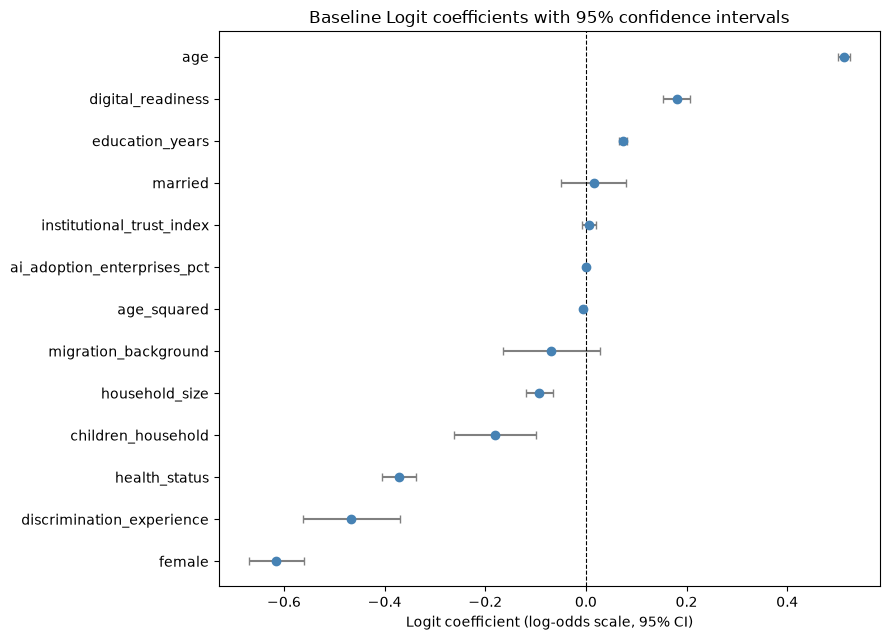

Saved coefficient plot to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\baseline_coefficients.png


In [28]:
plot_table = logit_table.loc[logit_table['variable'] != 'Intercept'].copy()
plot_table = plot_table.sort_values('coef')
errors = [plot_table['coef'] - plot_table['ci_low'], plot_table['ci_high'] - plot_table['coef']]

fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(plot_table))))
ax.errorbar(plot_table['coef'], plot_table['variable'], xerr=errors, fmt='o', color='steelblue', ecolor='gray', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Logit coefficient (log-odds scale, 95% CI)')
ax.set_title('Baseline Logit coefficients with 95% confidence intervals')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'baseline_coefficients.png', dpi=150)
plt.show()

print('Saved coefficient plot to:', FIGURES_DIR / 'baseline_coefficients.png')

In [29]:
interpretation_lines = [
    '# Baseline Econometric Interpretation',
    '',
    'Generated by notebooks/04_baseline_econometric_models.ipynb. All statements use',
    'association language only ("is associated with", "predicts", "correlates with") —',
    'no causal claims are made.',
    '',
    '## Modelling Sample',
    '',
    f'- Rows before listwise deletion: {n_before}',
    f'- Rows in final modelling sample: {n_after} ({n_dropped} dropped due to missing values)',
    f'- Variables used: {available_vars}',
    f'- Variables excluded (missing or unavailable): {missing_vars if missing_vars else "none"}',
    '',
    '## Model Comparison',
    '',
    model_comparison_table.to_markdown(index=False),
    '',
    '## Model Fit Diagnostics',
    '',
    'R-squared and Adjusted R-squared apply to Model 1 (LPM/OLS) only. McFadden pseudo-R-squared',
    'applies to Models 2-4 (Logit/Probit) only. AIC and BIC are directly comparable across all four',
    'models (lower values indicate better fit, penalizing model complexity).',
    '',
    fit_diagnostics_table.to_markdown(index=False),
    '',
    'Likelihood-ratio test of Model 2 (Logit) and Model 3 (Probit) against an intercept-only null model',
    '(and Model 4 against its own null, if estimated) -- a significant result (p < 0.05) indicates the full',
    'set of predictors jointly improves fit over an intercept-only model. Not applicable to Model 1 (LPM),',
    'which is assessed via R-squared/Adjusted R-squared above instead.',
    '',
    lr_vs_null_table.to_markdown(index=False),
    '',
]
if lr_nested_result is not None:
    interpretation_lines += [
        'Nested likelihood-ratio test: Model 2 (Logit, all variables) vs. a restricted Logit model with the',
        f"AI/education/gender/migration variable block removed ({', '.join(NESTED_TEST_DROPPED_VARS)}), testing",
        'their joint significance:',
        '',
        lr_nested_table.to_markdown(index=False),
        '',
    ]
else:
    interpretation_lines += [
        'Nested likelihood-ratio test for the AI/education/gender/migration block was not run (see notebook',
        'section 11a for the reason).',
        '',
    ]

if not hl_table.empty:
    interpretation_lines += [
        'Hosmer-Lemeshow goodness-of-fit test for the baseline Logit model (manually implemented; not built',
        'into statsmodels):',
        '',
        hl_table.to_markdown(index=False),
        '',
    ]
else:
    interpretation_lines += [
        f'Hosmer-Lemeshow goodness-of-fit test: not computed -- {hl_skip_reason}',
        '',
    ]

interpretation_lines += [
    '## Statistical Significance, Type I and Type II Error',
    '',
    'All hypothesis tests in this notebook use a significance level of alpha = 0.05. A p-value below 0.05',
    'is treated as statistically significant at the 5% level (Type I error risk: up to a 5% chance of a',
    'false positive if the true effect were zero). Failing to reject the null hypothesis (p >= 0.05) does',
    'NOT prove the null hypothesis is true -- it may reflect insufficient statistical power (Type II error',
    'risk: a false negative), especially for variables with smaller/weaker signal (e.g.,',
    'institutional_trust_index and children_household in this notebook) and for interaction terms estimated',
    'on smaller effective sample sizes in notebook 05.',
    '',
    '## Hypothesis-by-Hypothesis Interpretation',
    '',
]
for hyp, (text, _) in hypothesis_results.items():
    interpretation_lines.append(f'### {hyp}: {hypothesis_labels[hyp]}')
    interpretation_lines.append('')
    interpretation_lines.append(text)
    interpretation_lines.append('')

if fe_skip_reason:
    interpretation_lines += [
        '## Model 4 (Country Fixed Effects) Note',
        '',
        f'Model 4 was skipped: {fe_skip_reason}',
        '',
    ]

interpretation_path = REPORTS_DIR / 'baseline_econometric_interpretation.md'
with open(interpretation_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(interpretation_lines))

print('Saved baseline interpretation report to:', interpretation_path)
print('Next step: notebooks/05_advanced_econometric_models.ipynb')

Saved baseline interpretation report to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\reports\baseline_econometric_interpretation.md
Next step: notebooks/05_advanced_econometric_models.ipynb
